In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

           2
4.827e-14 x + 2.292e-07 x + 1.855


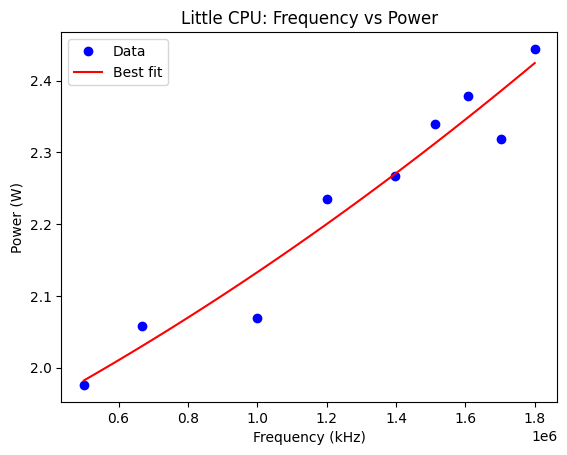

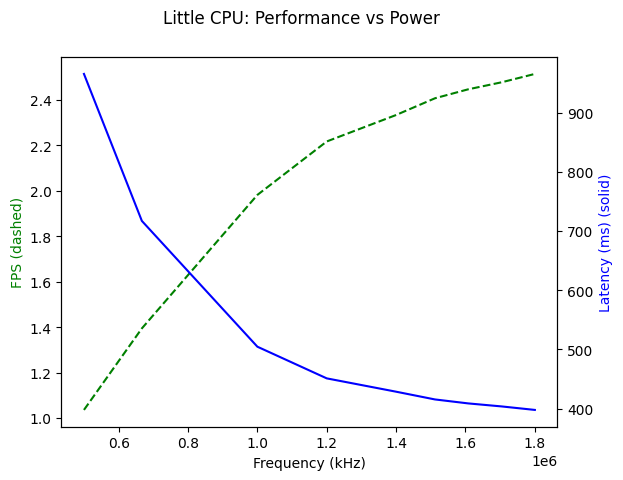

           2
6.998e-13 x - 7.705e-07 x + 2.523


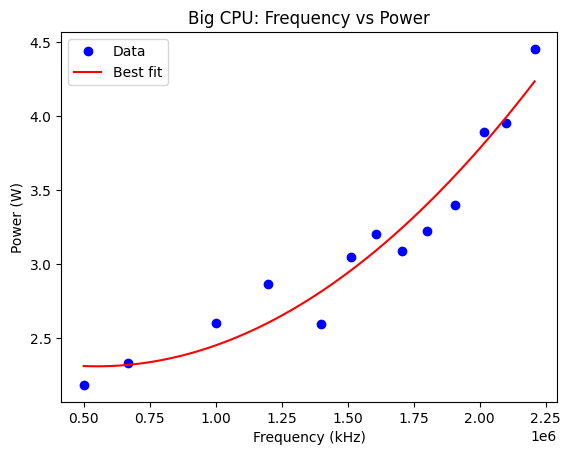

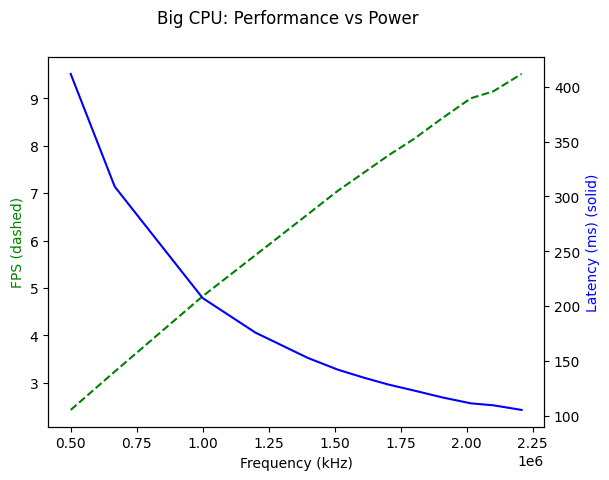

In [12]:
# EXPERIMENT 1 AND 2

data1 = pd.read_csv("data/exp1_little_cpu_20260116_120131.csv", header=1)
data2 = pd.read_csv("data/exp2_big_cpu_20260116_121717.csv", header=1)

def calc_best_fit_parabula(x, y):
    z = np.polyfit(x, y, 2)
    p = np.poly1d(z)

    print(p)

    xs = np.linspace(min(x), max(x), 100)
    ys = p(xs)

    return xs, ys

xs_little, ys_little = calc_best_fit_parabula(data1["little_freq"], data1["watts"])

plt.plot(data1["little_freq"], data1["watts"], "o", color="b", label="Data")
plt.plot(xs_little, ys_little, "-", color="r", label="Best fit")
plt.title("Little CPU: Frequency vs Power")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Power (W)")
plt.legend()
plt.show()

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(data1["little_freq"], data1["fps"], "--", color="g")
ax2.plot(data1["little_freq"], data1["latency"], "-", color="b")

fig.suptitle("Little CPU: Performance vs Power")
ax1.set_xlabel("Frequency (kHz)")
ax1.set_ylabel("FPS (dashed)", color="g")
ax2.set_ylabel("Latency (ms) (solid)", color="b")

plt.show()

xs_big, ys_big = calc_best_fit_parabula(data2["big_freq"], data2["watts"])
plt.plot(data2["big_freq"], data2["watts"], "o", color="b", label="Data")
plt.plot(xs_big, ys_big, "r-", label="Best fit")
plt.title("Big CPU: Frequency vs Power")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Power (W)")
plt.legend()
plt.show()

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(data2["big_freq"], data2["fps"], "--", color="g")
ax2.plot(data2["big_freq"], data2["latency"], "-", color="b")

fig.suptitle("Big CPU: Performance vs Power")
ax1.set_xlabel("Frequency (kHz)")
ax1.set_ylabel("FPS (dashed)", color="g")
ax2.set_ylabel("Latency (ms) (solid)", color="b")

plt.show()

Best fit plane: watts = 2.382e-07 * big_freq + 8.388e-08 * little_freq + 2.638


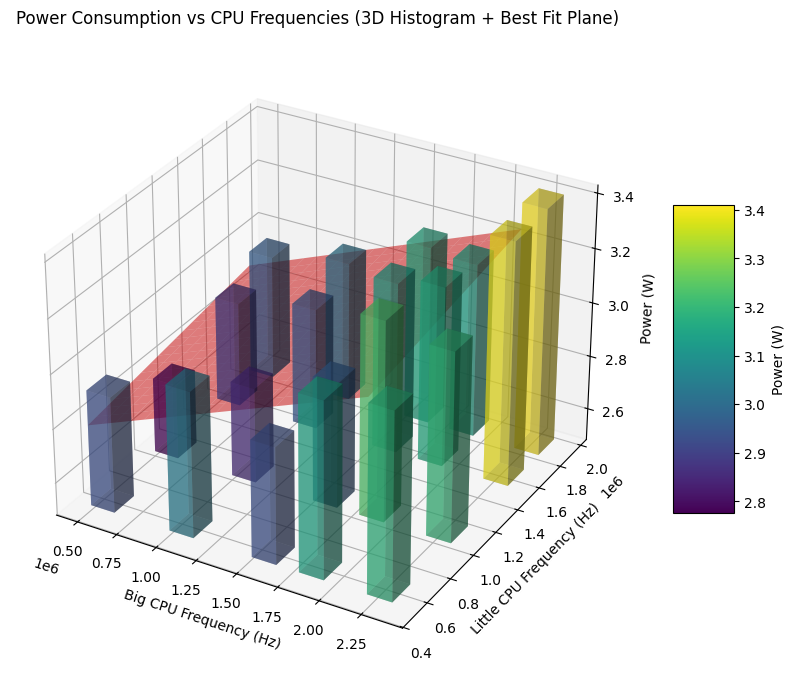

In [29]:
# EXPERIMENT 3

data3 = pd.read_csv("data/exp3_gpu_grid_20260117_194828.csv", header=1)

# Create 3D histogram
from mpl_toolkits.mplot3d import Axes3D

# Get data
big_freqs = data3["big_freq"].values
little_freqs = data3["little_freq"].values
watts = data3["watts"].values

# Fit a 2D plane: z = a*x + b*y + c
# Create design matrix A = [x, y, 1]
A = np.column_stack([big_freqs, little_freqs, np.ones_like(watts)])
# Solve least squares: A * [a, b, c]^T = watts
coeffs, _, _, _ = np.linalg.lstsq(A, watts, rcond=None)
a, b, c = coeffs

print(f"Best fit plane: watts = {a:.3e} * big_freq + {b:.3e} * little_freq + {c:.3f}")

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Calculate bar widths (thinner bars)
big_freq_unique = np.sort(np.unique(big_freqs))
little_freq_unique = np.sort(np.unique(little_freqs))
dx = (big_freq_unique[1] - big_freq_unique[0]) * 0.3 if len(big_freq_unique) > 1 else 50000
dy = (little_freq_unique[1] - little_freq_unique[0]) * 0.3 if len(little_freq_unique) > 1 else 50000

# Create bars starting at z=2 with height = watts - 2
z_base = 2.5
dz = watts - z_base

# Create 3D bars
colors = plt.cm.viridis((watts - watts.min()) / (watts.max() - watts.min()))
ax.bar3d(big_freqs, little_freqs, np.full_like(watts, z_base), dx, dy, dz, color=colors, alpha=0.5)

# Add best fit plane
big_range = np.linspace(big_freqs.min(), big_freqs.max(), 20)
little_range = np.linspace(little_freqs.min(), little_freqs.max(), 20)
X_plane, Y_plane = np.meshgrid(big_range, little_range)
Z_plane = a * X_plane + b * Y_plane + c

ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.5, color='red', edgecolor='none')

# Labels and title
ax.set_xlabel('Big CPU Frequency (Hz)', fontsize=10)
ax.set_ylabel('Little CPU Frequency (Hz)', fontsize=10)
ax.set_zlabel('Power (W)', fontsize=10)
ax.set_title('Power Consumption vs CPU Frequencies (3D Histogram + Best Fit Plane)', fontsize=12, pad=20)

# Add colorbar
mappable = plt.cm.ScalarMappable(cmap='viridis')
mappable.set_array(watts)
fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=5, label='Power (W)')

plt.show()